In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as stats
import seaborn as sns
import numpy as np
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [128]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()


,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0


In [129]:
# 원본데이터 결측치 개수, 비율
display(pd.DataFrame({
    'sum': df.isna().sum(),
    'ratio': df.isna().mean() * 100
}).sort_values('ratio', ascending=False).reset_index())

,index,sum,ratio
0,roles,641138,100.000000
1,incomplete_flag,540977,84.377622
2,nplay_video,457530,71.362172
3,nchapters,258753,40.358394
4,nevents,199151,31.062111
5,last_event_DI,178954,27.911932
6,ndays_act,162743,25.383459
7,LoE_DI,106008,16.534350
8,YoB,96605,15.067739
9,gender,86806,13.539363


In [130]:
# 전처리용 데이터 셋 생성
pre = df.copy()

In [131]:
### 컬럼명 소문자화
pre.columns = pre.columns.str.lower()

In [132]:
# 중복행 확인
pre.duplicated().sum()

np.int64(0)

In [133]:
# 의미없는 컬럼 제거
pre = pre.drop(columns=['index', 'roles'])

In [134]:
#데이터 형변환
# grade 숫자형으로 변환
pre['grade'] = pd.to_numeric(pre['grade'], errors='coerce')

In [135]:
# 파생컬럼 생성

# 학생들의 나이(age) & (age_segment)
pre['age'] = pre['start_time_di'].dt.year - pre['yob']

conditions = [
    pre['age'] >= 60,
    pre['age'] >= 50,
    pre['age'] >= 40,
    pre['age'] >= 30,
    pre['age'] >= 20,
]

choices = ['60s+', '50s', '40s', '30s', '20s']

pre['age_segment'] = np.select(conditions, choices, default='under 20')

# 퍼널 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'Certified',
        'Explored',
        'Viewed',
        'Registered'
    ],
    default='None'
)

# Missing Flag 컬럼 생성
missing_col = [
    'nchapters', 
    'nevents', 
    'ndays_act', 
    'nplay_video', 
    'last_event_di', 
    'age', 
    'grade']

for col in missing_col:
    pre[f'{col}_flag'] = pre[col].isna().astype(int)
    

# 학습 기간 (duration) 컬럼 생성
pre['duration'] = (pre['last_event_di'] - pre['start_time_di']).dt.days.astype(int, errors='ignore')

In [137]:
# 결측치 대체

# 성별 결측치(gender) : unknown 대체
pre['gender'] = pre['gender'].fillna('unknown')

# 학력 결측치(LoE_DI) : unknown 대체
pre['loe_di'] = pre['loe_di'].fillna('unknown')

# 탐색한 챕터 수 결측치(nchapters) : registered 단계일 때 0으로 대체
pre.loc[
    (pre['step']=='Registered') & (pre['nchapters'].isna()),
    'nchapters'
] = 0

# 총 이벤트 발생 수 결측치(nevent) : registered 단계일 때 0으로 대체
pre['nevents'] = pre[pre['step']=='Registered']['nevents'].fillna(0)

# # 활성 일수 결측치(ndays_act) : 0으로 대체
# pre['ndays_act'] = pre['ndays_act'].fillna(0)

# 영상재생횟수(nplay_video) 결측치 : 논의중

# 마지막 이벤트 발생일 (last_event_DI) : 논의중

# 나이 (age) 결측치 : 논의중

# 성적(grade) 결측치 : 논의중




In [118]:
# 행제거
print('행 제거 작업 시작 전:')
print(pre.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (pre['viewed'] == 0) & (pre['explored'] == 1)
funnel_mask2 = (pre['explored'] == 0) & (pre['certified'] == 1)
pre = pre[~funnel_mask1]
pre = pre[~funnel_mask2]

# durration 음수 행 제거
duration_mask = pre['duration'] < 0
pre = pre[~duration_mask]

# age 13세 미만 행 제거
age_mask = pre['age'] < 13
pre = pre[~age_mask]

# 상시 개방된 강의 제거 
course_mask = (pre['course_id'] =='HarvardX/CS50x/2012') | (pre['course_id'] =='HarvardX/ER22x/2013_Spring') | (pre['course_id'] =='HarvardX/CB22x/2013_Spring')
pre = pre[~course_mask]

# incomplete_flag == 1 제외
pre = pre[pre['incomplete_flag'].isna()]

print('행 제거 작업 후:')
print(pre.shape)

행 제거 작업 시작 전:
(641138, 30)


C:\Users\gmltk\AppData\Local\Temp\ipykernel_561712\1135363942.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = pre[~funnel_mask2]


행 제거 작업 후:
(355438, 30)


In [122]:
# 강의별 공식 일정 테이블 생성 & merge

# 1. course_id별 공식 일정 매핑표
schedule_map = {
    # HarvardX
    'HarvardX/PH207x/2012_Fall': {
        'course_title': 'Health in Numbers: Quantitative Methods in Clinical & Public Health Research',
        'registration_open': '2012-07-24',
        'course_launch': '2012-10-15',
        'course_wrap': '2013-01-30'
    },
    'HarvardX/CS50x/2012': {
        'course_title': 'Introduction to Computer Science I',
        'registration_open': '2012-07-24',
        'course_launch': '2012-10-15',
                'course_wrap': '2013-04-15'
        },
        'HarvardX/HLS1x/2013_Spring': {
                'course_title': 'Copyright',
                'registration_open': '2012-12-19',
                'course_launch': '2013-01-28',
                'course_wrap': '2013-07-03'
        },
        'HarvardX/ER22x/2013_Spring': {
                'course_title': 'Justice',
                'registration_open': '2012-12-19',
                'course_launch': '2013-03-02',
                'course_wrap': '2013-07-26'
        },
        'HarvardX/CB22x/2013_Spring': {
                'course_title': 'The Ancient Greek Hero',
                'registration_open': '2012-12-19',
                'course_launch': '2013-03-13',
                'course_wrap': '2013-08-26'
        },
        'HarvardX/PH278x/2013_Spring': {
                'course_title': 'Human Health and Global Environmental Change',
                'registration_open': '2012-12-19',
                'course_launch': '2013-05-15',
                'course_wrap': '2013-07-25'
        },

        # MITx
        'MITx/6.002x/2012_Fall': {
                'course_title': 'Circuits and Electronics - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-09-05',
                'course_wrap': '2012-12-25'
        },
        'MITx/6.00x/2012_Fall': {
                'course_title': 'Introduction to Computer Science and Programming - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-09-26',
                'course_wrap': '2013-01-15'
        },
        'MITx/3.091x/2012_Fall': {
                'course_title': 'Introduction to Solid State Chemistry - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-10-09',
                'course_wrap': '2013-01-15'
        },
        'MITx/6.00x/2013_Spring': {
                'course_title': 'Introduction to Computer Science and Programming - Spring',
                'registration_open': '2012-12-19',
                'course_launch': '2013-02-04',
                'course_wrap': '2013-06-04'
        },
        'MITx/3.091x/2013_Spring': {
                'course_title': 'Introduction to Solid State Chemistry - Spring',
                'registration_open': '2012-12-20',
                'course_launch': '2013-02-05',
                'course_wrap': '2013-06-21'
        },
        'MITx/14.73x/2013_Spring': {
                'course_title': 'The Challenges of Global Poverty',
                'registration_open': '2012-12-19',
                'course_launch': '2013-02-12',
                'course_wrap': '2013-05-21'
        },
        'MITx/8.02x/2013_Spring': {
                'course_title': 'Electricity and Magnetism',
                'registration_open': '2013-01-17',
                'course_launch': '2013-02-18',
                'course_wrap': '2013-06-18'
        },
        'MITx/6.002x/2013_Spring': {
                'course_title': 'Circuits and Electronics - Spring',
                'registration_open': '2012-12-20',
                'course_launch': '2013-03-03',
                'course_wrap': '2013-07-01'
        },
        'MITx/7.00x/2013_Spring': {
                'course_title': 'Introduction to Biology - The Secret of Life',
                'registration_open': '2013-01-30',
                'course_launch': '2013-03-05',
                'course_wrap': '2013-06-06'
        },
        'MITx/2.01x/2013_Spring': {
                'course_title': 'Elements of Structures',
                'registration_open': '2013-02-24',
                'course_launch': '2013-04-15',
                'course_wrap': '2013-07-30'
        },
        'MITx/8.MReV/2013_Summer': {
                'course_title': 'Mechanics ReView',
                'registration_open': '2013-04-27',
                'course_launch': '2013-06-01',
                'course_wrap': '2013-09-15'
        }
}

# 2. dict -> DataFrame 변환
schedule_df = (
        pd.DataFrame(schedule_map)
        .T
        .reset_index()
        .rename(columns={'index': 'course_id'})
)

# 3. 날짜형 변환
date_cols = ['registration_open', 'course_launch', 'course_wrap']
for col in date_cols:
        schedule_df[col] = pd.to_datetime(schedule_df[col])

# pre = pd.merge()

In [88]:
display(schedule_df)

,course_id,course_title,registration_open,course_launch,course_wrap
0,HarvardX/PH207x/2012_Fall,Health in Numbers: Quantitative Methods in Cli...,2012-07-24,2012-10-15,2013-01-30
1,HarvardX/CS50x/2012,Introduction to Computer Science I,2012-07-24,2012-10-15,2013-04-15
2,HarvardX/HLS1x/2013_Spring,Copyright,2012-12-19,2013-01-28,2013-07-03
3,HarvardX/ER22x/2013_Spring,Justice,2012-12-19,2013-03-02,2013-07-26
4,HarvardX/CB22x/2013_Spring,The Ancient Greek Hero,2012-12-19,2013-03-13,2013-08-26
5,HarvardX/PH278x/2013_Spring,Human Health and Global Environmental Change,2012-12-19,2013-05-15,2013-07-25
6,MITx/6.002x/2012_Fall,Circuits and Electronics - Fall,2012-07-24,2012-09-05,2012-12-25
7,MITx/6.00x/2012_Fall,Introduction to Computer Science and Programmi...,2012-07-24,2012-09-26,2013-01-15
8,MITx/3.091x/2012_Fall,Introduction to Solid State Chemistry - Fall,2012-07-24,2012-10-09,2013-01-15
9,MITx/6.00x/2013_Spring,Introduction to Computer Science and Programmi...,2012-12-19,2013-02-04,2013-06-04


In [89]:
# 2차 컬럼 drop
pre = pre.drop(columns=['yob', 'incomplete_flag'])

<Axes: >

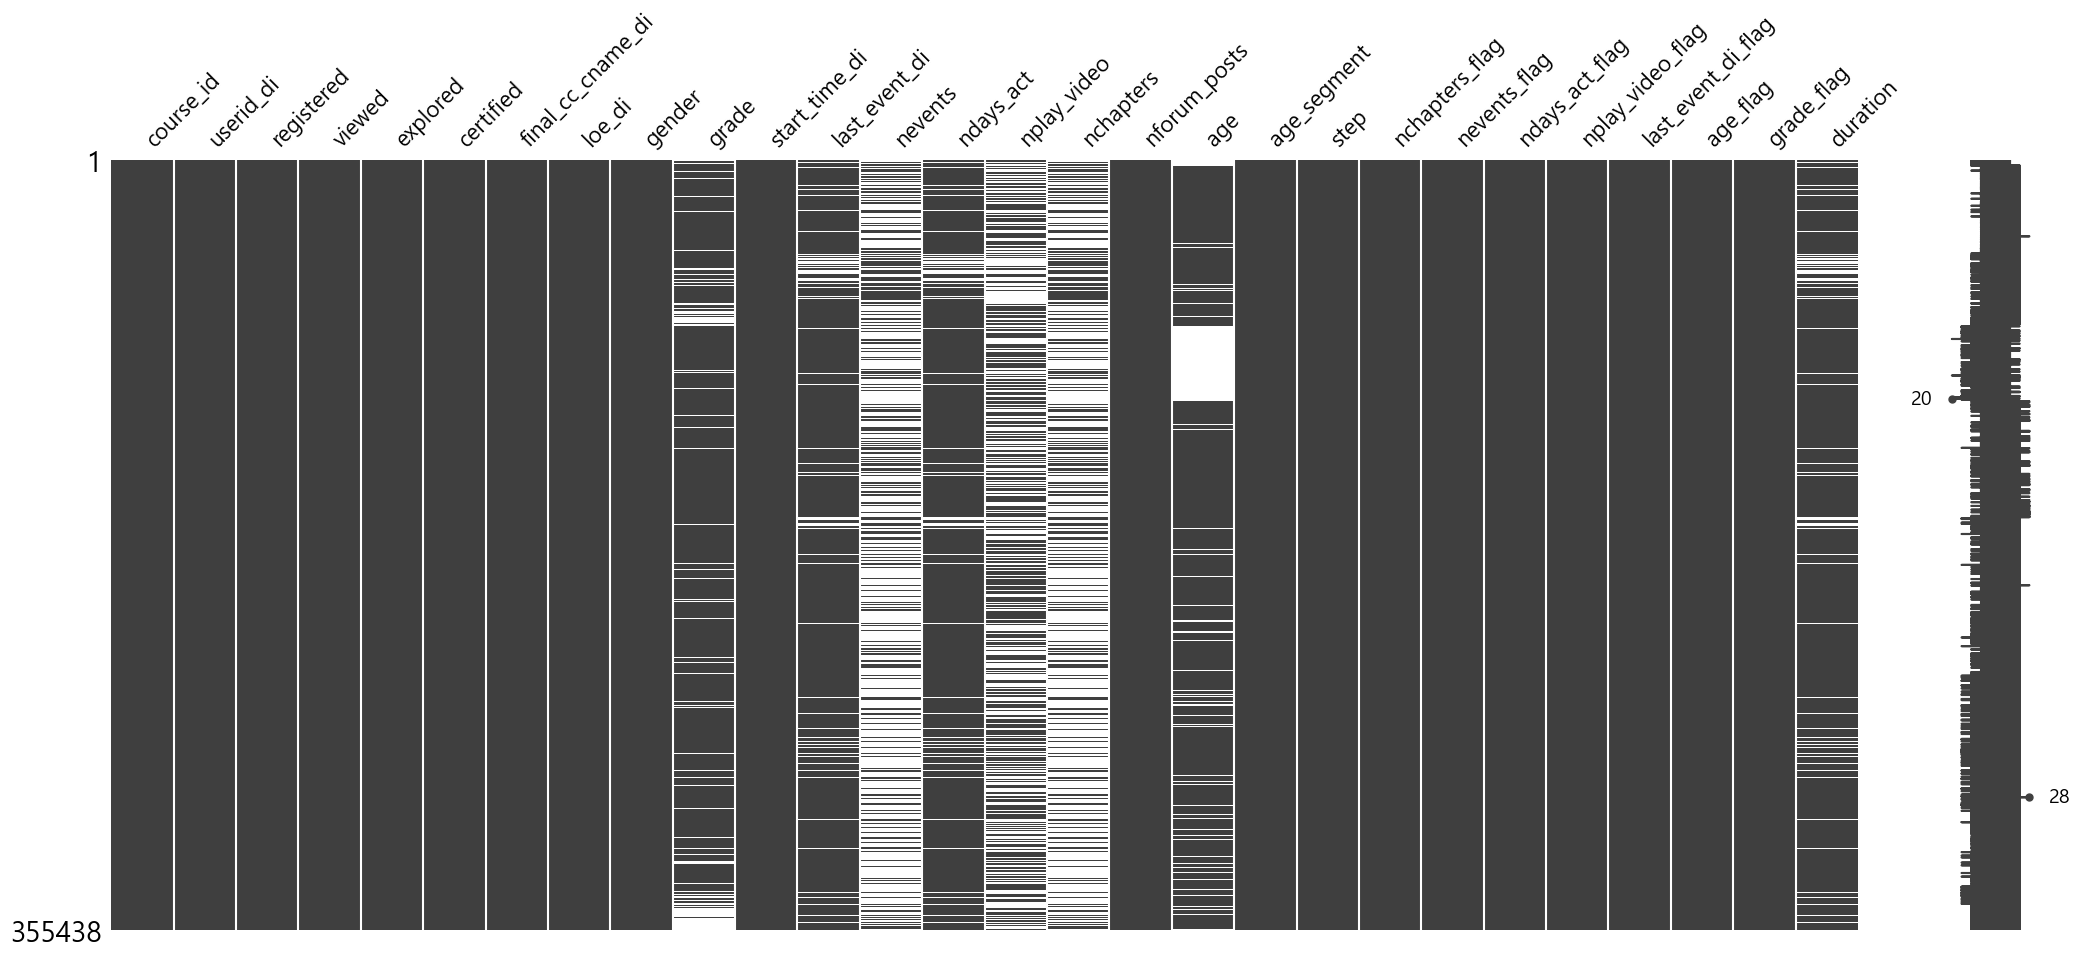

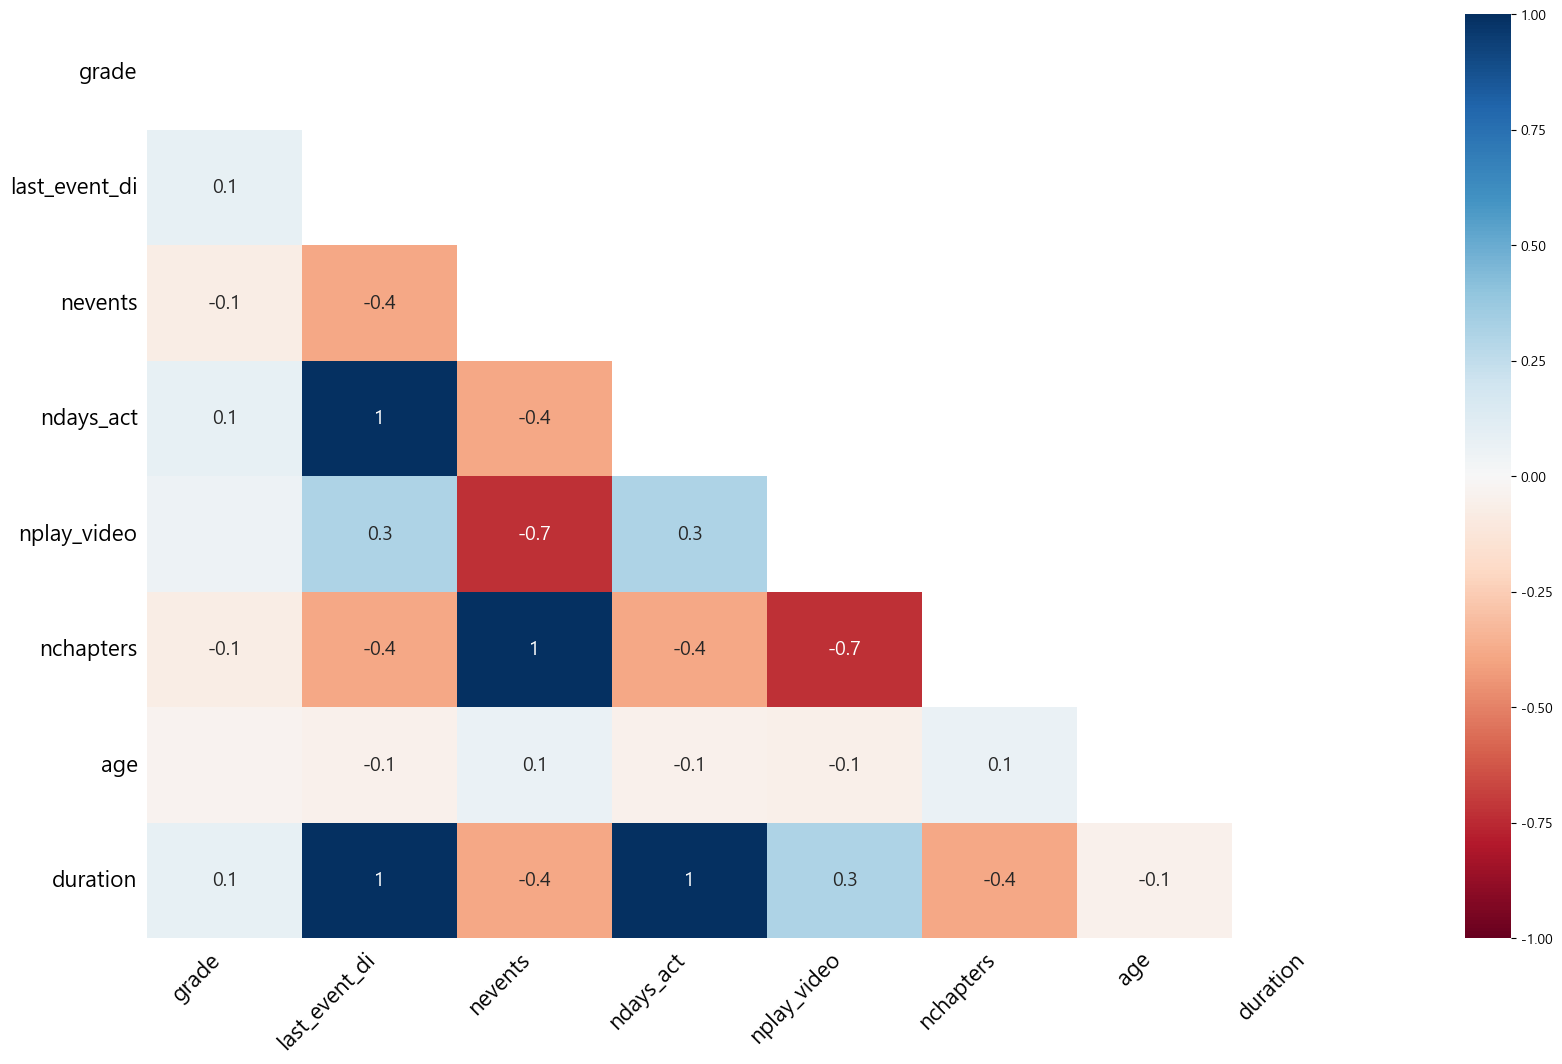

In [90]:
import missingno as msno
msno.matrix(pre)
msno.heatmap(pre)

In [91]:
pre.isna().sum()

course_id                  0
userid_di                  0
registered                 0
viewed                     0
explored                   0
certified                  0
final_cc_cname_di          0
loe_di                     0
gender                     0
grade                  37807
start_time_di              0
last_event_di          29858
nevents               235209
ndays_act              29858
nplay_video           174389
nchapters             235209
nforum_posts               0
age                    58978
age_segment                0
step                       0
nchapters_flag             0
nevents_flag               0
ndays_act_flag             0
nplay_video_flag           0
last_event_di_flag         0
age_flag                   0
grade_flag                 0
duration               29858
dtype: int64

In [92]:
pre[pre['grade'] == 0].notna().sum()

course_id             253089
userid_di             253089
registered            253089
viewed                253089
explored              253089
certified             253089
final_cc_cname_di     253089
loe_di                253089
gender                253089
grade                 253089
start_time_di         253089
last_event_di         229022
nevents               103679
ndays_act             229022
nplay_video           105574
nchapters             103679
nforum_posts          253089
age                   212338
age_segment           253089
step                  253089
nchapters_flag        253089
nevents_flag          253089
ndays_act_flag        253089
nplay_video_flag      253089
last_event_di_flag    253089
age_flag              253089
grade_flag            253089
duration              229022
dtype: int64

In [93]:
pre[pre['grade'].isna()].notna().sum()

course_id             37807
userid_di             37807
registered            37807
viewed                37807
explored              37807
certified             37807
final_cc_cname_di     37807
loe_di                37807
gender                37807
grade                     0
start_time_di         37807
last_event_di         32020
nevents               16546
ndays_act             32020
nplay_video           16638
nchapters             16546
nforum_posts          37807
age                   33050
age_segment           37807
step                  37807
nchapters_flag        37807
nevents_flag          37807
ndays_act_flag        37807
nplay_video_flag      37807
last_event_di_flag    37807
age_flag              37807
grade_flag            37807
duration              32020
dtype: int64

<Axes: >

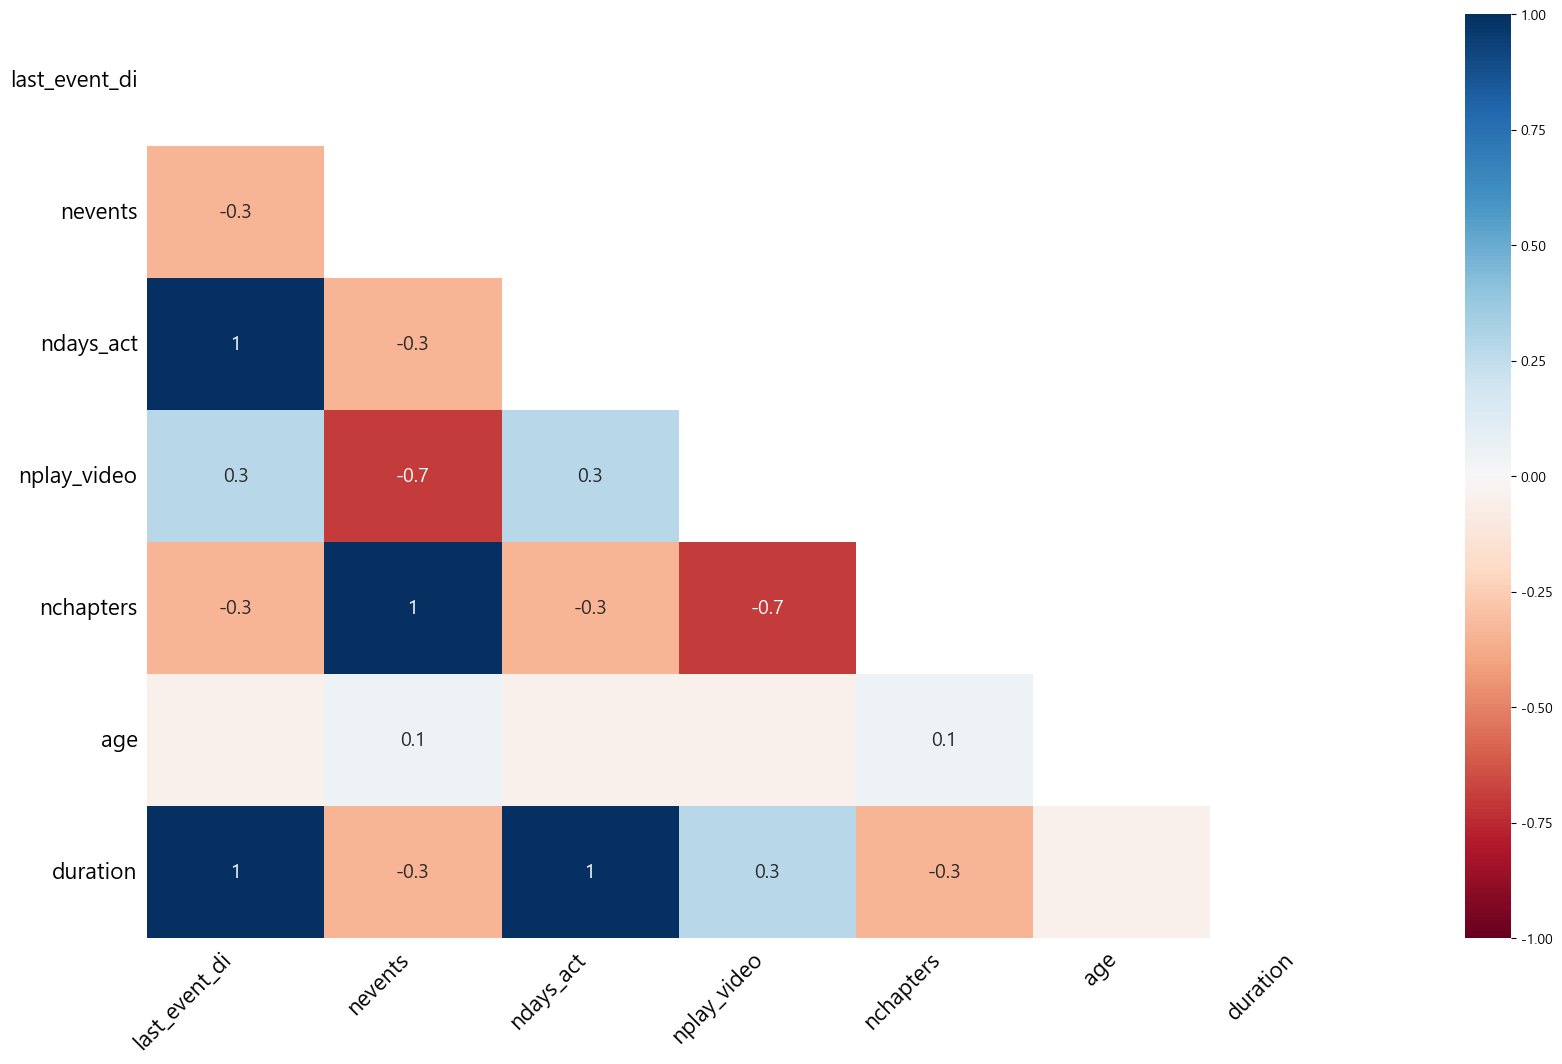

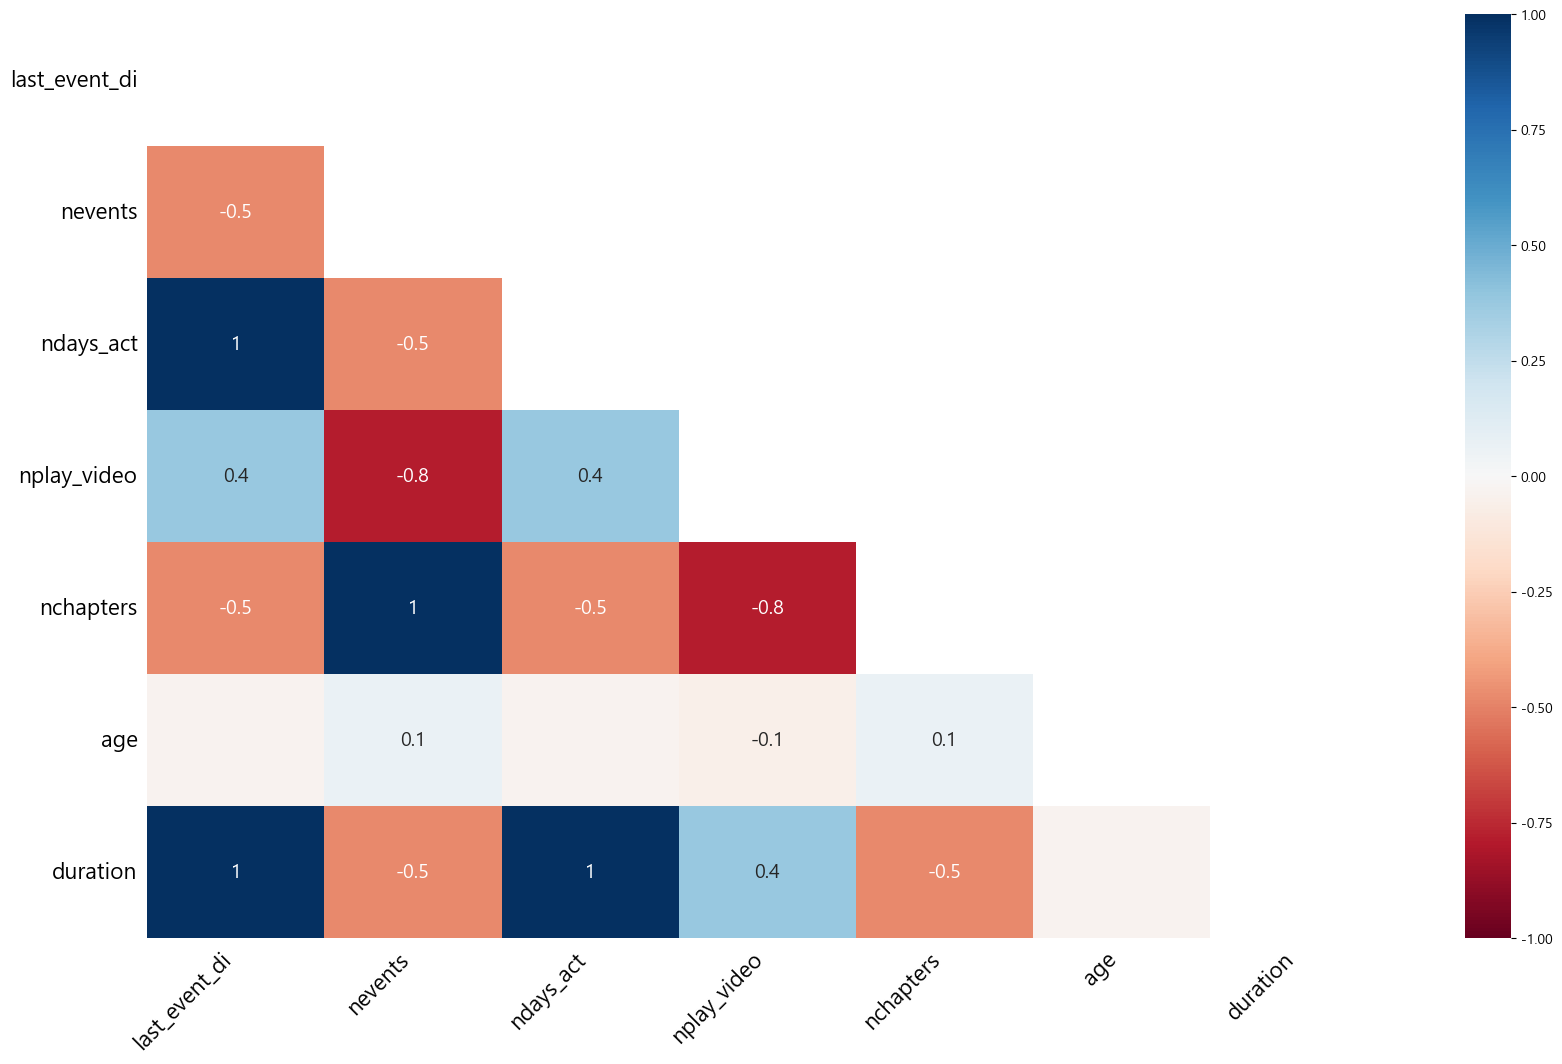

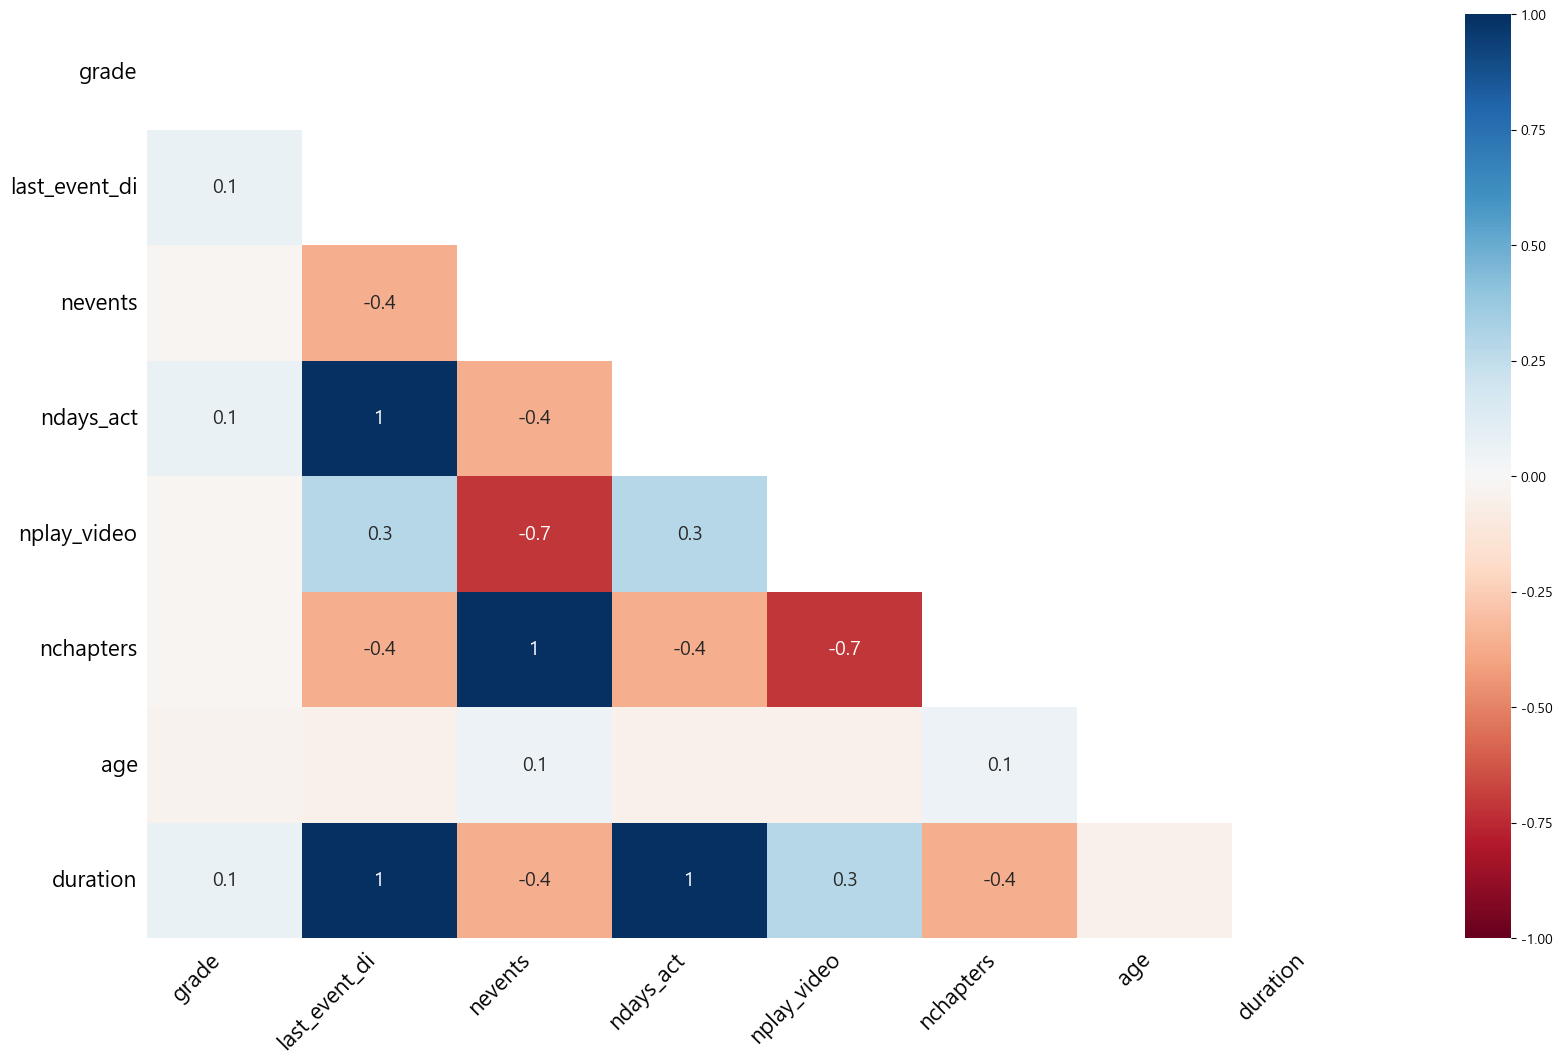

In [94]:
temp1 = pre[pre['grade']==0]
temp2 = pre[pre['grade'].isna()]
temp3 = pre[
    (pre['grade']==0) |
    (pre['grade'].isna())
]


msno.heatmap(temp1)
msno.heatmap(temp2)
msno.heatmap(temp3)


In [95]:
pre.groupby('course_id')[['nchapters', 'nevents']].apply(lambda x: x.isna().sum())

,nchapters,nevents
course_id,,
HarvardX/PH207x/2012_Fall,24200,24200
HarvardX/PH278x/2013_Spring,14915,14915
MITx/14.73x/2013_Spring,15711,15711
MITx/2.01x/2013_Spring,3864,3864
MITx/3.091x/2012_Fall,6991,6991
MITx/3.091x/2013_Spring,5130,5130
MITx/6.002x/2012_Fall,24887,24887
MITx/6.002x/2013_Spring,10607,10607
MITx/6.00x/2012_Fall,41261,41261


In [96]:
tmp = pre.groupby('course_id').apply(lambda x: x.isna().mean())
tmp[['last_event_di', 'ndays_act', 'nevents', 'nchapters']]

,last_event_di,ndays_act,nevents,nchapters
course_id,,,,
HarvardX/PH207x/2012_Fall,0.082853,0.082853,0.589023,0.589023
HarvardX/PH278x/2013_Spring,0.265008,0.265008,0.421745,0.421745
MITx/14.73x/2013_Spring,0.103027,0.103027,0.624965,0.624965
MITx/2.01x/2013_Spring,0.023625,0.023625,0.696844,0.696844
MITx/3.091x/2012_Fall,0.052484,0.052484,0.502624,0.502624
MITx/3.091x/2013_Spring,0.045901,0.045901,0.969022,0.969022
MITx/6.002x/2012_Fall,0.050997,0.050997,0.640015,0.640015
MITx/6.002x/2013_Spring,0.067220,0.067220,0.546358,0.546358
MITx/6.00x/2012_Fall,0.058263,0.058263,0.625385,0.625385


In [97]:
pre.groupby('course_id').size()


course_id
HarvardX/PH207x/2012_Fall      41085
HarvardX/PH278x/2013_Spring    35365
MITx/14.73x/2013_Spring        25139
MITx/2.01x/2013_Spring          5545
MITx/3.091x/2012_Fall          13909
MITx/3.091x/2013_Spring         5294
MITx/6.002x/2012_Fall          38885
MITx/6.002x/2013_Spring        19414
MITx/6.00x/2012_Fall           65977
MITx/6.00x/2013_Spring         50618
MITx/7.00x/2013_Spring         19504
MITx/8.02x/2013_Spring         25870
MITx/8.MReV/2013_Summer         8833
dtype: int64

In [98]:
pre.groupby('course_id')['certified'].mean()

course_id
HarvardX/PH207x/2012_Fall      0.044761
HarvardX/PH278x/2013_Spring    0.018012
MITx/14.73x/2013_Spring        0.082541
MITx/2.01x/2013_Spring         0.044364
MITx/3.091x/2012_Fall          0.045438
MITx/3.091x/2013_Spring        0.020212
MITx/6.002x/2012_Fall          0.044567
MITx/6.002x/2013_Spring        0.029463
MITx/6.00x/2012_Fall           0.037089
MITx/6.00x/2013_Spring         0.024734
MITx/7.00x/2013_Spring         0.040915
MITx/8.02x/2013_Spring         0.031736
MITx/8.MReV/2013_Summer        0.030228
Name: certified, dtype: float64

In [107]:
pre[
    (pre['nchapters'].isna())&
    (pre['certified'] == 1)
].shape


(13426, 29)

In [101]:
pre.groupby('course_id')[['nchapters', 'nevents']].apply(lambda x: x.isna().mean())

,nchapters,nevents
course_id,,
HarvardX/PH207x/2012_Fall,0.589023,0.589023
HarvardX/PH278x/2013_Spring,0.421745,0.421745
MITx/14.73x/2013_Spring,0.624965,0.624965
MITx/2.01x/2013_Spring,0.696844,0.696844
MITx/3.091x/2012_Fall,0.502624,0.502624
MITx/3.091x/2013_Spring,0.969022,0.969022
MITx/6.002x/2012_Fall,0.640015,0.640015
MITx/6.002x/2013_Spring,0.546358,0.546358
MITx/6.00x/2012_Fall,0.625385,0.625385


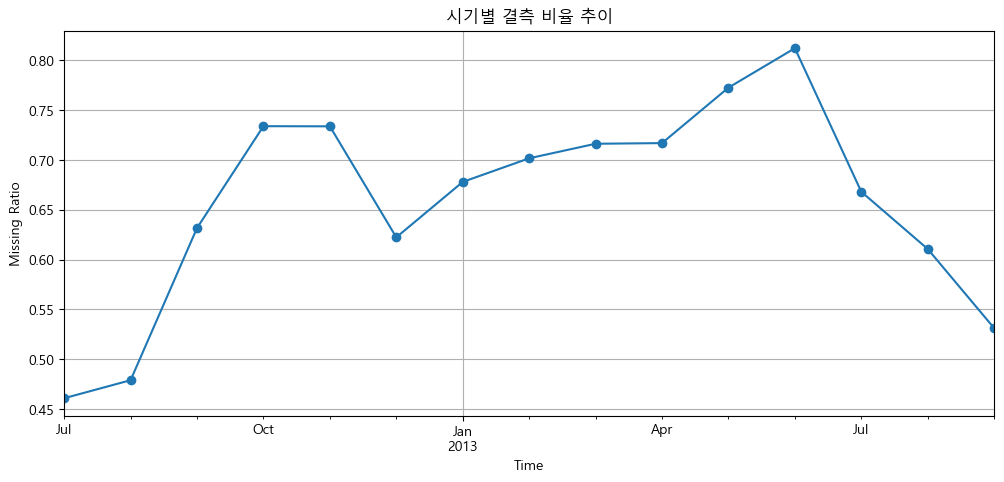

In [102]:
pre['year_month'] = pre['start_time_di'].dt.to_period('M')

missing_trend = pre.groupby('year_month')['nchapters'].apply(lambda x: x.isna().mean().mean())

missing_trend.plot(figsize=(12,5), marker='o')
plt.title("시기별 결측 비율 추이")
plt.ylabel("Missing Ratio")
plt.xlabel("Time")
plt.grid()
plt.show()

In [103]:
missing_by_course = (
    pre.groupby('course_id')
       .apply(lambda x: x.isna().mean())
       .reset_index()
)

missing_by_course.head()

,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,age,age_segment,step,nchapters_flag,nevents_flag,ndays_act_flag,nplay_video_flag,last_event_di_flag,age_flag,grade_flag,duration,year_month
0,HarvardX/PH207x/2012_Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.137568,0.0,0.082853,0.589023,0.082853,0.496434,0.589023,0.0,0.078691,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.082853,0.0
1,HarvardX/PH278x/2013_Spring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.178312,0.0,0.265008,0.421745,0.265008,0.647505,0.421745,0.0,0.087488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.265008,0.0
2,MITx/14.73x/2013_Spring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.061657,0.0,0.103027,0.624965,0.103027,0.497116,0.624965,0.0,0.112932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.103027,0.0
3,MITx/2.01x/2013_Spring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.084941,0.0,0.023625,0.696844,0.023625,0.438233,0.696844,0.0,0.252660,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023625,0.0
4,MITx/3.091x/2012_Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.068732,0.0,0.052484,0.502624,0.052484,0.573873,0.502624,0.0,0.192969,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.052484,0.0


In [104]:
pre[
    (pre['nevents'].isna())&
    (pre['ndays_act']==0)
].head(20)

,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,age,age_segment,step,nchapters_flag,nevents_flag,ndays_act_flag,nplay_video_flag,last_event_di_flag,age_flag,grade_flag,duration,year_month


In [105]:
pre[
    (pre['step'] == 'Viewed') &
    (pre['ndays_act'] == 0)
].shape

(0, 29)